In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import roc_auc_score

In [51]:
np.random.seed(42)
n_samples = 1000

data = pd.DataFrame({
    "email_length": np.random.normal(120, 40, n_samples),
    "capital_letters": np.random.poisson(5, n_samples),
    "exclamation_marks": np.random.poisson(2, n_samples),
    "spam_keywords": np.random.poisson(1, n_samples),
    "contains_link": np.random.binomial(1, 0.3, n_samples)
})

# Create label with weighted logic
data["label"] = (
    (data["capital_letters"] > 8) |
    (data["exclamation_marks"] > 3) |
    (data["spam_keywords"] > 2) |
    (data["contains_link"] == 1)
).astype(int)

print(data.head())

   email_length  capital_letters  exclamation_marks  spam_keywords  \
0    139.868566                4                  2              0   
1    114.469428                7                  0              0   
2    145.907542                7                  3              0   
3    180.921194                2                  1              0   
4    110.633865                5                  1              1   

   contains_link  label  
0              0      0  
1              0      0  
2              0      0  
3              0      0  
4              1      1  


In [52]:
X = data.drop("label", axis=1)
y = data["label"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [53]:
scaler = StandardScaler()

XTrainScaled = scaler.fit_transform(X_train)
XTestScaled = scaler.transform(X_test)

# Compatibility aliases for snake_case snippets
X_train_scaled = XTrainScaled
X_test_scaled = XTestScaled


In [54]:
knn = KNeighborsClassifier()

knn.fit(XTrainScaled, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [55]:
model = LogisticRegression()

model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [56]:
y_pred_knn = knn.predict(XTestScaled)

y_prob_knn = knn.predict_proba(XTestScaled)[:, 1]

y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

knnacc = accuracy_score(y_test, y_pred_knn)
knnauc = roc_auc_score(y_test, y_prob_knn)

print("Logistic Regression Accuracy:", acc)
print("Logistic Regression AUC:", auc)

print("KNN Accuracy:", knnacc)
print("KNN AUC:", knnauc)

Logistic Regression Accuracy: 0.885
Logistic Regression AUC: 0.9629286376274329
KNN Accuracy: 0.97
KNN AUC: 0.9978375038616003


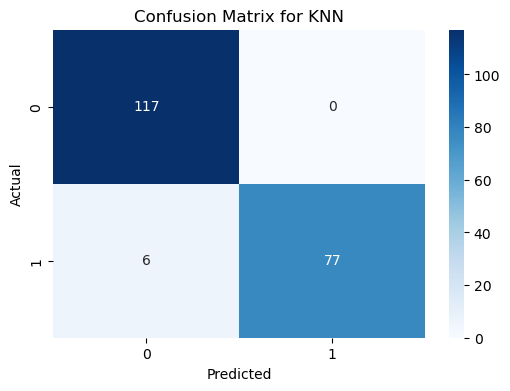

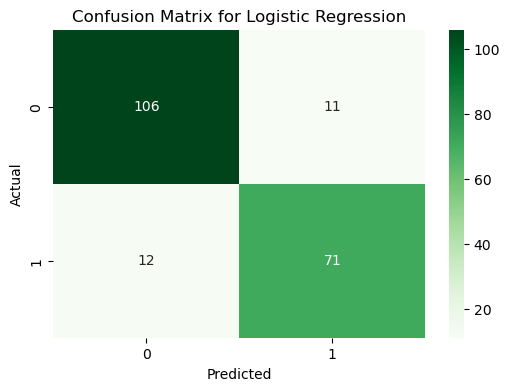

In [57]:
knnMatrix = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(6,4))
sns.heatmap(knnMatrix, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix for KNN")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

logRegressionMatrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(logRegressionMatrix, annot=True, fmt="d", cmap="Greens")
plt.title("Confusion Matrix for Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

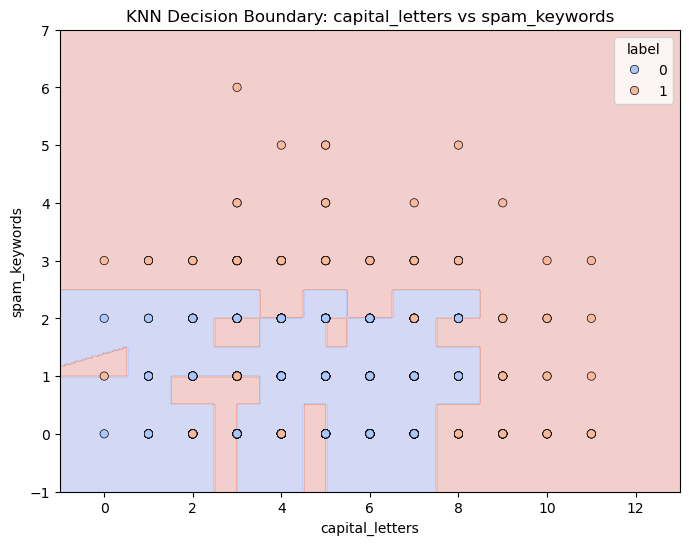

In [58]:
viz_cols = ["capital_letters", "spam_keywords"]
X_viz = data[viz_cols]
y_viz = data["label"]

X_train_viz, X_test_viz, y_train_viz, y_test_viz = train_test_split(
    X_viz, y_viz, test_size=0.2, random_state=42, stratify=y_viz
)

scaler_viz = StandardScaler()
X_train_viz_scaled = scaler_viz.fit_transform(X_train_viz)

knn_viz = KNeighborsClassifier(n_neighbors=5)
knn_viz.fit(X_train_viz_scaled, y_train_viz)

x_min, x_max = X_viz["capital_letters"].min() - 1, X_viz["capital_letters"].max() + 1
y_min, y_max = X_viz["spam_keywords"].min() - 1, X_viz["spam_keywords"].max() + 1
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

grid = pd.DataFrame(np.c_[xx.ravel(), yy.ravel()], columns=viz_cols)
Z = knn_viz.predict(scaler_viz.transform(grid)).reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.25, cmap="coolwarm")
sns.scatterplot(
    x=X_train_viz["capital_letters"],
    y=X_train_viz["spam_keywords"],
    hue=y_train_viz,
    palette="coolwarm",
    edgecolor="k"
)
plt.title("KNN Decision Boundary: capital_letters vs spam_keywords")
plt.xlabel("capital_letters")
plt.ylabel("spam_keywords")
plt.show()

Class order: [0 1]
             feature  coefficient  odds_ratio
4      contains_link     6.509754  671.661147
2  exclamation_marks     1.117659    3.057687
3      spam_keywords     0.984091    2.675379
1    capital_letters     0.385318    1.470081
0       email_length     0.000214    1.000214


C:\Users\legen\AppData\Local\Temp\ipykernel_2216\4149495042.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=coef_df, x="coefficient", y="feature", palette="coolwarm")


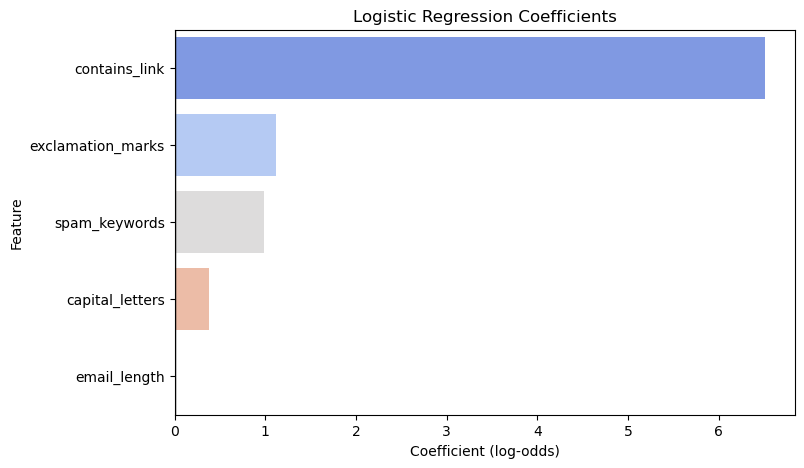

In [59]:
coef_df = pd.DataFrame({
    "feature": X_train.columns,
    "coefficient": model.coef_[0]
})
coef_df["odds_ratio"] = np.exp(coef_df["coefficient"])
coef_df["abs_coef"] = coef_df["coefficient"].abs()
coef_df = coef_df.sort_values("abs_coef", ascending=False)

print("Class order:", model.classes_)
print(coef_df[["feature", "coefficient", "odds_ratio"]])

plt.figure(figsize=(8, 5))
sns.barplot(data=coef_df, x="coefficient", y="feature", palette="coolwarm")
plt.axvline(0, color="black", linewidth=1)
plt.title("Logistic Regression Coefficients")
plt.xlabel("Coefficient (log-odds)")
plt.ylabel("Feature")
plt.show()

     model  noise_std  accuracy
0      KNN        0.0     0.970
1   LogReg        0.0     0.880
2      KNN        0.1     0.965
3   LogReg        0.1     0.915
4      KNN        0.2     0.975
5   LogReg        0.2     0.865
6      KNN        0.3     0.945
7   LogReg        0.3     0.845
8      KNN        0.5     0.895
9   LogReg        0.5     0.815
10     KNN        0.8     0.800
11  LogReg        0.8     0.740


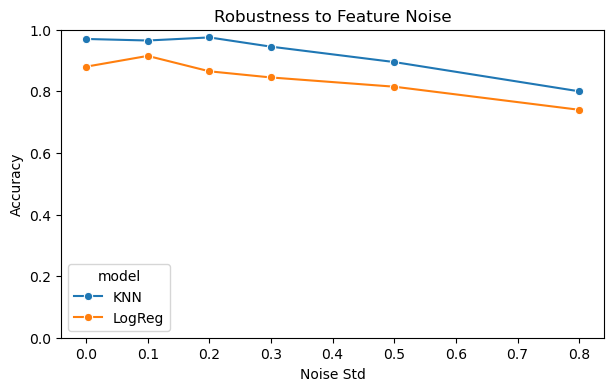

In [60]:
rng = np.random.default_rng(42)
noise_levels = [0.0, 0.1, 0.2, 0.3, 0.5, 0.8]

results = []

for std in noise_levels:
    X_test_noisy = XTestScaled + rng.normal(0, std, XTestScaled.shape)

    for name, clf in models.items():
        clf.fit(XTrainScaled, y_train)
        y_pred_noisy = clf.predict(X_test_noisy)

        results.append({
            "model": name,
            "noise_std": std,
            "accuracy": accuracy_score(y_test, y_pred_noisy)
        })

results_df = pd.DataFrame(results)
print(results_df)

plt.figure(figsize=(7, 4))
sns.lineplot(data=results_df, x="noise_std", y="accuracy", hue="model", marker="o")
plt.title("Robustness to Feature Noise")
plt.xlabel("Noise Std")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.show()